# Preprocesamiento de Datos

## Minería de Datos

El objetivo de esta etapa es preparar el conjunto de datos para los análisis posteriores de clasificación y clustering.

El preprocesamiento incluye:

- Exploración de la estructura de los datos.
- Identificación de variables numéricas y categóricas.
- Identificación de valores faltantes.
- Revisión de valores duplicados.
- Identificación de posibles valores atípicos.
- Transformación de variables.
- Construcción de una variable binaria de popularidad.
- Preparación de las variables para los modelos.

In [ ]:
# NO ejecutar esta celda

import sys
import subprocess
import importlib

required_packages = {
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "missingno": "missingno",
    "sklearn": "scikit-learn"
}

for module_name, pip_name in required_packages.items():
    try:
        importlib.import_module(module_name)
        print(f"✓ {module_name} ya está instalado")
    except ImportError:
        print(f"✗ Instalando {pip_name}...")
        subprocess.check_call([
            sys.executable,
            "-m",
            "pip",
            "install",
            pip_name
        ])

print("\nTodas las dependencias están listas.")

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.3f}".format)

## 2. Carga del dataset

El conjunto de datos contiene canciones que aparecieron en los rankings Spotify Top 200 desde 2016.

Cada observación corresponde a una canción e incluye información sobre el artista, características musicales y desempeño dentro de los rankings.

In [2]:
path = "/home/yagoh/Escritorio/Personal/dev/Educacion/Diplomado-Tecnicas-Estadisticas-y-Mineria-de-Datos/Unidad_3/Data/spotify_top_songs_audio_features.csv"

df = pd.read_csv(path)

df.head(10)

,id,artist_names,track_name,source,key,mode,time_signature,danceability,energy,speechiness,acousticness,instrumentalness,liveness,valence,loudness,tempo,duration_ms,weeks_on_chart,streams
0,000xQL6tZNLJzIrtIgxqSl,"ZAYN, PARTYNEXTDOOR",Still Got Time (feat. PARTYNEXTDOOR),RCA Records Label,G,Major,4 beats,0.748,0.627,0.064,0.131,0.000,0.085,0.524,-6.029,120.963,188491,17,107527761
1,003eoIwxETJujVWmNFMoZy,Alessia Cara,Growing Pains,Def Jam Recordings,C#/Db,Minor,4 beats,0.353,0.755,0.733,0.082,0.000,0.390,0.437,-6.276,191.153,193680,2,9944865
2,003vvx7Niy0yvhvHt4a68B,The Killers,Mr. Brightside,Island Records,C#/Db,Major,4 beats,0.352,0.911,0.075,0.001,0.000,0.100,0.236,-5.230,148.033,222973,125,512388123
3,00B7TZ0Xawar6NZ00JFomN,"Cardi B, Chance the Rapper",Best Life (feat. Chance The Rapper),Atlantic/KSR,A,Major,4 beats,0.620,0.625,0.553,0.287,0.000,0.314,0.665,-7.438,167.911,284856,2,11985346
4,00Blm7zeNqgYLPtW6zg8cj,"Post Malone, The Weeknd",One Right Now (with The Weeknd),Republic Records,C#/Db,Major,4 beats,0.687,0.781,0.053,0.036,0.000,0.075,0.688,-4.806,97.014,193507,30,301860377
5,00EPIEnX1JFjff8sC6bccd,"Thalia, NATTI NATASHA",No Me Acuerdo,Sony Music Latin,G,Minor,4 beats,0.836,0.799,0.087,0.187,0.000,0.092,0.772,-4.247,94.033,217653,16,98123727
6,00ETaeHUQ6lops3oWU1Wrt,"Kygo, Donna Summer",Hot Stuff,RCA Records Label,F,Major,4 beats,0.681,0.773,0.148,0.019,0.000,0.110,0.429,-5.749,119.961,199008,1,4569978
7,00ZKeP47bZtswtANkvxz2j,"Tropa do Bruxo, DJ Ws da Igrejinha, SMU, Triz,...",Baile do Bruxo,Tropa Do Bruxo,G,Minor,5 beats,0.734,0.228,0.530,0.889,0.006,0.102,0.522,-4.731,162.524,221538,3,27916960
8,00gpGR84M27moP7AFuqHIx,YBN Nahmir,Bounce Out With That,2018,G#/Ab,Major,4 beats,0.857,0.560,0.173,0.043,0.000,0.153,0.482,-8.278,94.949,91011,6,4913180
9,00imgaPlYRrMGn9o83hfmk,Brent Faiyaz,LOOSE CHANGE,"Lost Kids LLC., Marketed by Venice / Stem",C#/Db,Minor,4 beats,0.574,0.369,0.081,0.753,0.000,0.147,0.440,-8.931,84.975,226011,1,5854629


## 3. Exploración inicial

Antes de realizar transformaciones se revisará la estructura general del conjunto de datos.

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6513 entries, 0 to 6512
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                6513 non-null   str    
 1   artist_names      6513 non-null   str    
 2   track_name        6513 non-null   str    
 3   source            6513 non-null   str    
 4   key               6513 non-null   str    
 5   mode              6513 non-null   str    
 6   time_signature    6513 non-null   str    
 7   danceability      6513 non-null   float64
 8   energy            6513 non-null   float64
 9   speechiness       6513 non-null   float64
 10  acousticness      6513 non-null   float64
 11  instrumentalness  6513 non-null   float64
 12  liveness          6513 non-null   float64
 13  valence           6513 non-null   float64
 14  loudness          6513 non-null   float64
 15  tempo             6513 non-null   float64
 16  duration_ms       6513 non-null   int64  
 17  weeks_

In [4]:
print(f"Observaciones: {df.shape[0]:,}")
print(f"Variables: {df.shape[1]}")

Observaciones: 6,513
Variables: 19


In [5]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,6513,6513,000xQL6tZNLJzIrtIgxqSl,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
artist_names,6513,3001,Taylor Swift,175,NaN,NaN,NaN,NaN,NaN,NaN,NaN
track_name,6513,5351,Sleigh Ride,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
source,6513,967,Columbia,317,NaN,NaN,NaN,NaN,NaN,NaN,NaN
key,6513,12,C#/Db,942,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mode,6513,2,Major,3747,NaN,NaN,NaN,NaN,NaN,NaN,NaN
time_signature,6513,4,4 beats,6057,NaN,NaN,NaN,NaN,NaN,NaN,NaN
danceability,6513.000,NaN,NaN,NaN,0.682,0.142,0.150,0.591,0.698,0.785,0.985
energy,6513.000,NaN,NaN,NaN,0.637,0.165,0.022,0.534,0.651,0.759,0.989
speechiness,6513.000,NaN,NaN,NaN,0.122,0.113,0.023,0.044,0.072,0.163,0.966


## 4. Tipos de variables

Las variables se clasifican inicialmente en numéricas y categóricas.

Esta clasificación será útil para decidir qué transformaciones pueden aplicarse posteriormente.

In [24]:
num_vars = df.select_dtypes(
    include=np.number
).columns

cat_vars = df.select_dtypes(
    exclude=np.number
).columns

print("Variables numéricas:", len(num_vars))
print(num_vars.tolist())

print("\nVariables categóricas:", len(cat_vars))
print(cat_vars.tolist())

Variables numéricas: 12
['danceability', 'energy', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'loudness', 'tempo', 'duration_ms', 'weeks_on_chart', 'streams']

Variables categóricas: 7
['id', 'artist_names', 'track_name', 'source', 'key', 'mode', 'time_signature']


## 5. Número de valores únicos

Se revisará el número de valores distintos de cada variable.

Esto permite identificar variables que funcionan como identificadores, variables categóricas con pocas categorías y variables con una gran cantidad de valores diferentes.

In [6]:
for col in df.columns:
    print(
        f"{col:25} → "
        f"{df[col].nunique():,} valores únicos"
    )

id                        → 6,513 valores únicos
artist_names              → 3,001 valores únicos
track_name                → 5,351 valores únicos
source                    → 967 valores únicos
key                       → 12 valores únicos
mode                      → 2 valores únicos
time_signature            → 4 valores únicos
danceability              → 686 valores únicos
energy                    → 805 valores únicos
speechiness               → 1,146 valores únicos
acousticness              → 2,020 valores únicos
instrumentalness          → 1,833 valores únicos
liveness                  → 1,071 valores únicos
valence                   → 1,013 valores únicos
loudness                  → 4,255 valores únicos
tempo                     → 5,353 valores únicos
duration_ms               → 5,460 valores únicos
weeks_on_chart            → 159 valores únicos
streams                   → 6,513 valores únicos


## 6. Identificadores

Algunas variables identifican directamente una canción o proporcionan información descriptiva sobre ella.

Por ejemplo:

- `id`: identificador de Spotify.
- `track_name`: nombre de la canción.
- `artist_names`: artista o artistas.
- `source`: sello discográfico.

Estas variables pueden ser útiles para interpretar los resultados, pero no se utilizarán directamente como variables predictoras en los modelos numéricos.

In [26]:
df[
    ["id", "track_name", "artist_names", "source"]
].head()

,id,track_name,artist_names,source
0,000xQL6tZNLJzIrtIgxqSl,Still Got Time (feat. PARTYNEXTDOOR),"ZAYN, PARTYNEXTDOOR",RCA Records Label
1,003eoIwxETJujVWmNFMoZy,Growing Pains,Alessia Cara,Def Jam Recordings
2,003vvx7Niy0yvhvHt4a68B,Mr. Brightside,The Killers,Island Records
3,00B7TZ0Xawar6NZ00JFomN,Best Life (feat. Chance The Rapper),"Cardi B, Chance the Rapper",Atlantic/KSR
4,00Blm7zeNqgYLPtW6zg8cj,One Right Now (with The Weeknd),"Post Malone, The Weeknd",Republic Records


## 7. Valores faltantes

Los valores faltantes pueden afectar tanto el entrenamiento de modelos como el cálculo de distancias utilizado por K-means.

Primero se identificará su cantidad y distribución antes de decidir cómo tratarlos.

### Introducción de valores faltantes

Para practicar posteriormente diferentes técnicas de imputación, se introducirán de manera controlada algunos valores faltantes en el conjunto de datos.

Los valores faltantes serán simulados únicamente en variables numéricas relacionadas con las características musicales y el desempeño de las canciones.

Se conservará una copia del dataset original para poder comparar los datos antes y después del proceso de imputación.

En un problema real, los valores faltantes deben analizarse para determinar por qué se producen. En este ejercicio, la ausencia de valores es simulada con fines didácticos.m

In [7]:
# Copia del dataset original
df_missing = df.copy()

# Variables donde se introducirán valores faltantes
missing_cols = [
    "danceability",
    "energy",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "loudness",
    "tempo",
    "duration_ms",
    "weeks_on_chart",
    "streams"
]

MISSING_RATE = 0.03

np.random.seed(123)

for col in missing_cols:
    missing_idx = np.random.choice(
        df_missing.index,
        size=int(len(df_missing) * MISSING_RATE),
        replace=False
    )

    df_missing.loc[missing_idx, col] = np.nan

In [8]:
missing_summary = (
    df_missing[missing_cols]
    .isna()
    .sum()
    .to_frame("missing")
)

missing_summary["percentage"] = (
    missing_summary["missing"] /
    len(df) * 100
)

missing_summary

,missing,percentage
danceability,195,2.994
energy,195,2.994
speechiness,195,2.994
acousticness,195,2.994
instrumentalness,195,2.994
liveness,195,2.994
valence,195,2.994
loudness,195,2.994
tempo,195,2.994
duration_ms,195,2.994


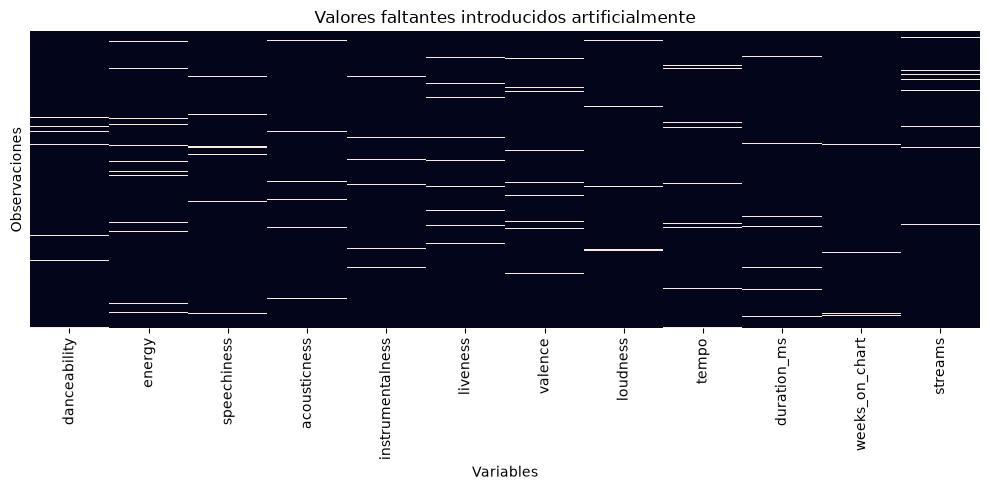

In [9]:
plt.figure(figsize=(10, 5))

sns.heatmap(
    df_missing[missing_cols].isna(),
    cbar=False,
    yticklabels=False
)

plt.title("Valores faltantes introducidos artificialmente")
plt.xlabel("Variables")
plt.ylabel("Observaciones")

plt.tight_layout()
plt.show()

In [10]:
df_median = df_missing.copy()

for col in missing_cols:
    df_median[col] = df_median[col].fillna(
        df_median[col].median()
    )

print("Valores faltantes después de imputación:")
print(df_median[missing_cols].isna().sum().sum())

Valores faltantes después de imputación:
0


In [31]:
from sklearn.impute import KNNImputer

df_knn = df_missing.copy()

imputer = KNNImputer(
    n_neighbors=5
)

df_knn[missing_cols] = imputer.fit_transform(
    df_knn[missing_cols]
)

print("Valores faltantes después de KNN:")
print(df_knn[missing_cols].isna().sum().sum())

Valores faltantes después de KNN:
0


In [32]:
variable = "danceability"

comparison = pd.DataFrame({
    "Original": df[variable],
    "Con_NA": df_missing[variable],
    "Mediana": df_median[variable],
    "KNN": df_knn[variable]
})

comparison.head(10)

,Original,Con_NA,Mediana,KNN
0,0.748,0.748,0.748,0.748
1,0.353,0.353,0.353,0.353
2,0.352,0.352,0.352,0.352
3,0.620,0.620,0.620,0.620
4,0.687,NaN,0.698,0.766
5,0.836,0.836,0.836,0.836
6,0.681,0.681,0.681,0.681
7,0.734,0.734,0.734,0.734
8,0.857,0.857,0.857,0.857
9,0.574,NaN,0.698,0.571


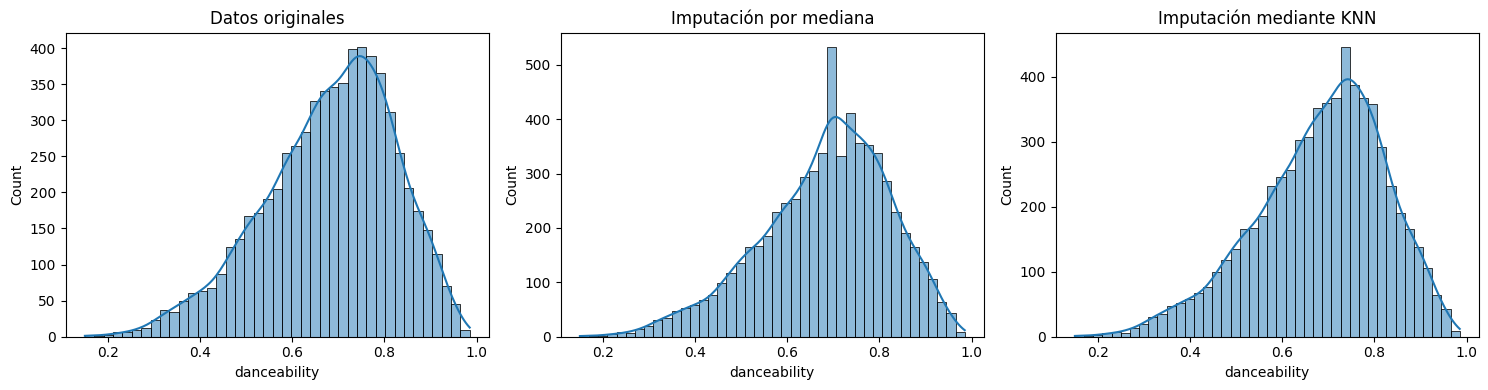

In [34]:
fig, axes = plt.subplots(
    1, 3,
    figsize=(15, 4)
)

sns.histplot(
    df[variable],
    kde=True,
    ax=axes[0]
)

axes[0].set_title("Datos originales")

sns.histplot(
    df_median[variable],
    kde=True,
    ax=axes[1]
)

axes[1].set_title("Imputación por mediana")

sns.histplot(
    df_knn[variable],
    kde=True,
    ax=axes[2]
)

axes[2].set_title("Imputación mediante KNN")

plt.tight_layout()
plt.show()

## 8. Registros duplicados

También es necesario verificar si existen observaciones duplicadas.

En este dataset, el identificador `id` permite realizar una segunda comprobación, ya que idealmente cada canción debería aparecer una sola vez.

In [35]:
print(
    "Filas duplicadas:",
    df.duplicated().sum()
)

print(
    "IDs duplicados:",
    df["id"].duplicated().sum()
)

Filas duplicadas: 0
IDs duplicados: 0


## 9. Características musicales

Las variables musicales constituyen el principal conjunto de variables que se utilizará para los modelos.

Entre ellas se encuentran medidas como:

- `danceability`: qué tan adecuada es una canción para bailar.
- `energy`: intensidad y actividad de la canción.
- `speechiness`: presencia de palabras habladas.
- `acousticness`: probabilidad de que una canción sea acústica.
- `instrumentalness`: probabilidad de que no contenga voces.
- `liveness`: probabilidad de que haya sido grabada en vivo.
- `valence`: positividad musical percibida.
- `loudness`: volumen general en decibeles.
- `tempo`: tempo estimado en BPM.
- `duration_ms`: duración en milisegundos.

In [36]:
audio_features = [
    "danceability",
    "energy",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "loudness",
    "tempo",
    "duration_ms"
]

df[audio_features].describe().T

,count,mean,std,min,25%,50%,75%,max
danceability,6513.000,0.682,0.142,0.150,0.591,0.698,0.785,0.985
energy,6513.000,0.637,0.165,0.022,0.534,0.651,0.759,0.989
speechiness,6513.000,0.122,0.113,0.023,0.044,0.072,0.163,0.966
acousticness,6513.000,0.237,0.245,0.000,0.044,0.145,0.356,0.994
instrumentalness,6513.000,0.012,0.075,0.000,0.000,0.000,0.000,0.953
liveness,6513.000,0.180,0.138,0.020,0.097,0.124,0.219,0.977
valence,6513.000,0.492,0.227,0.032,0.316,0.489,0.669,0.982
loudness,6513.000,-6.351,2.536,-34.475,-7.564,-5.983,-4.673,1.509
tempo,6513.000,122.117,29.416,46.718,98.007,120.034,142.025,212.117
duration_ms,6513.000,202566.684,49199.592,30133.000,173038.000,198367.000,226003.000,690732.000


## 10. Distribución de las características musicales

Se visualizarán las distribuciones de las características musicales para identificar asimetrías, concentraciones de valores y posibles valores extremos.

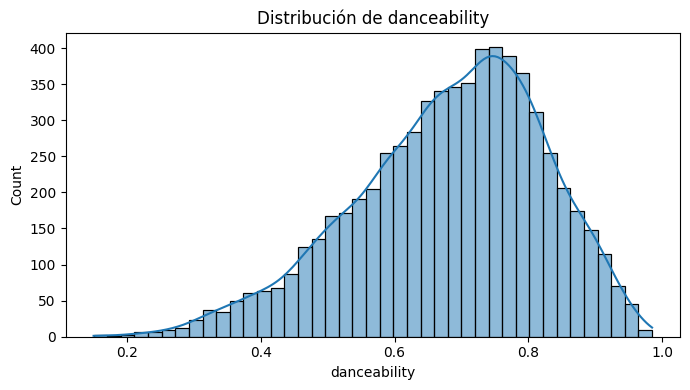

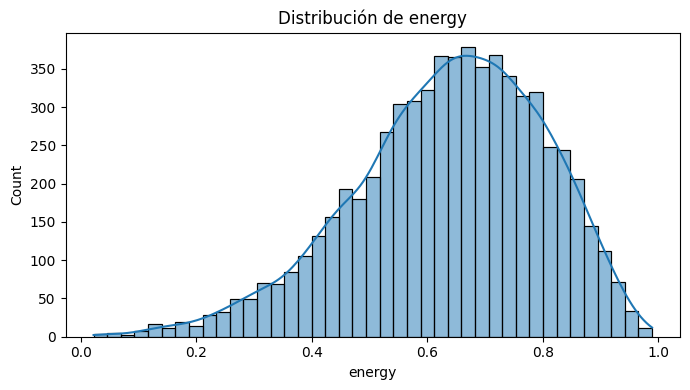

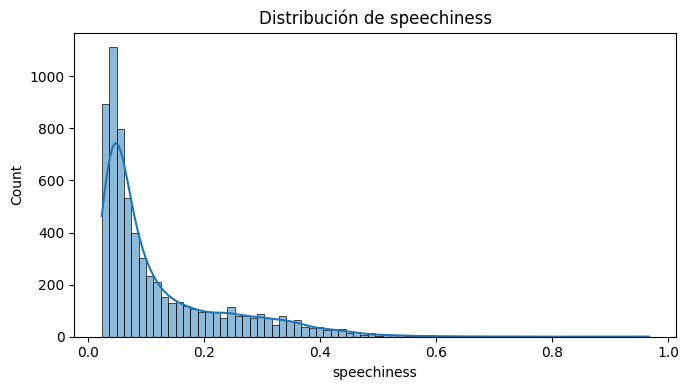

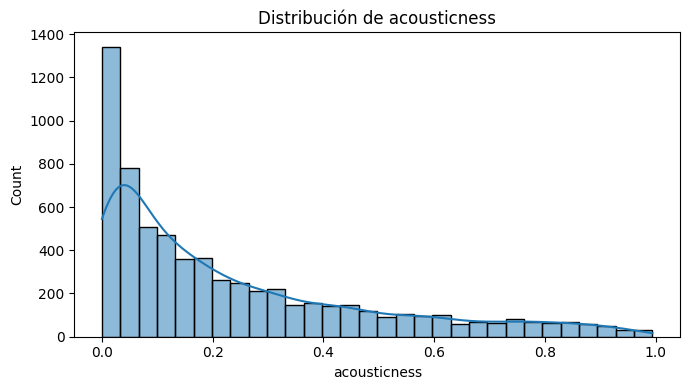

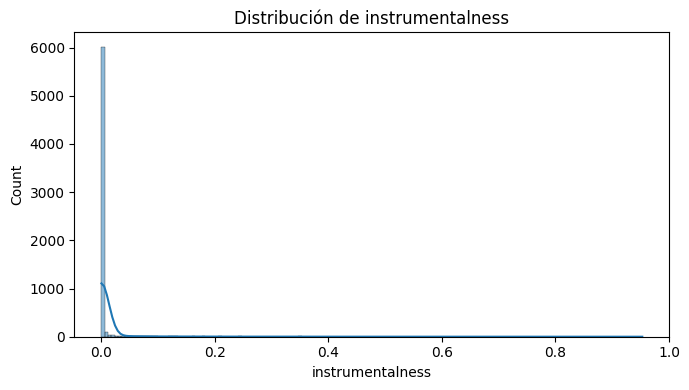

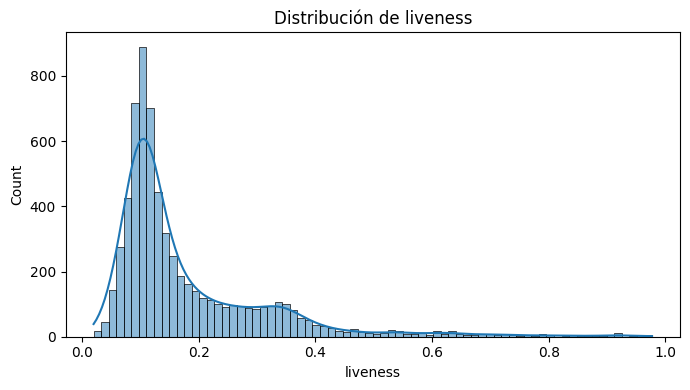

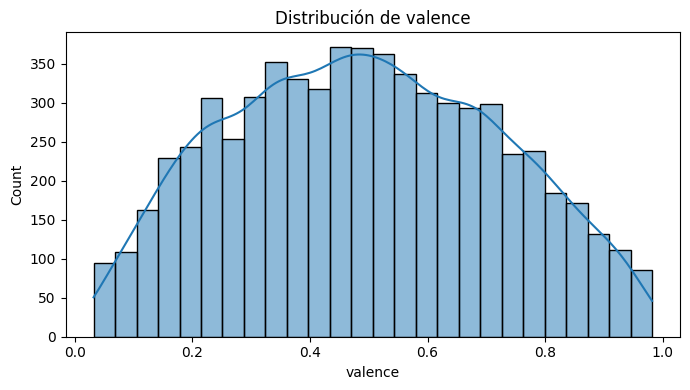

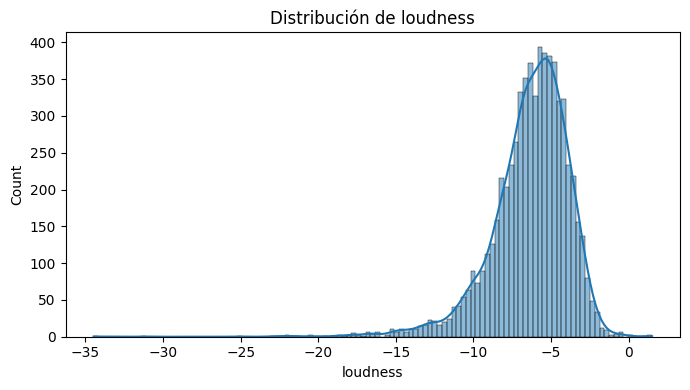

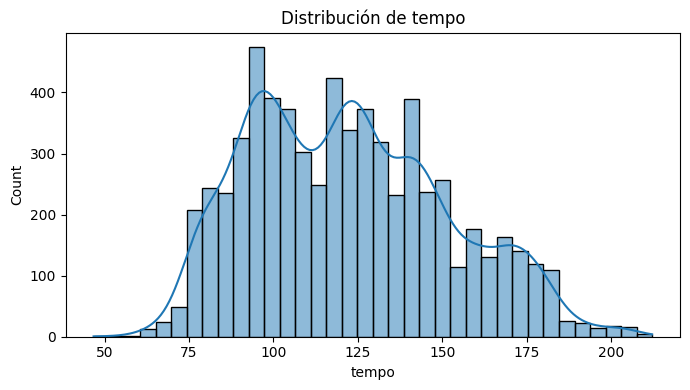

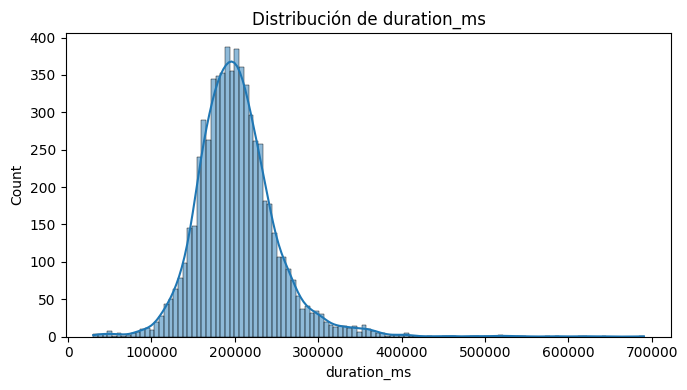

In [37]:
for col in audio_features:
    
    plt.figure(figsize=(7, 4))
    
    sns.histplot(
        data=df,
        x=col,
        kde=True
    )
    
    plt.title(f"Distribución de {col}")
    plt.tight_layout()
    plt.show()

## 11. Relación entre características musicales

La matriz de correlaciones permite identificar relaciones lineales entre las características musicales.

Esto será especialmente importante para comprender la estructura de los datos antes de aplicar los modelos.

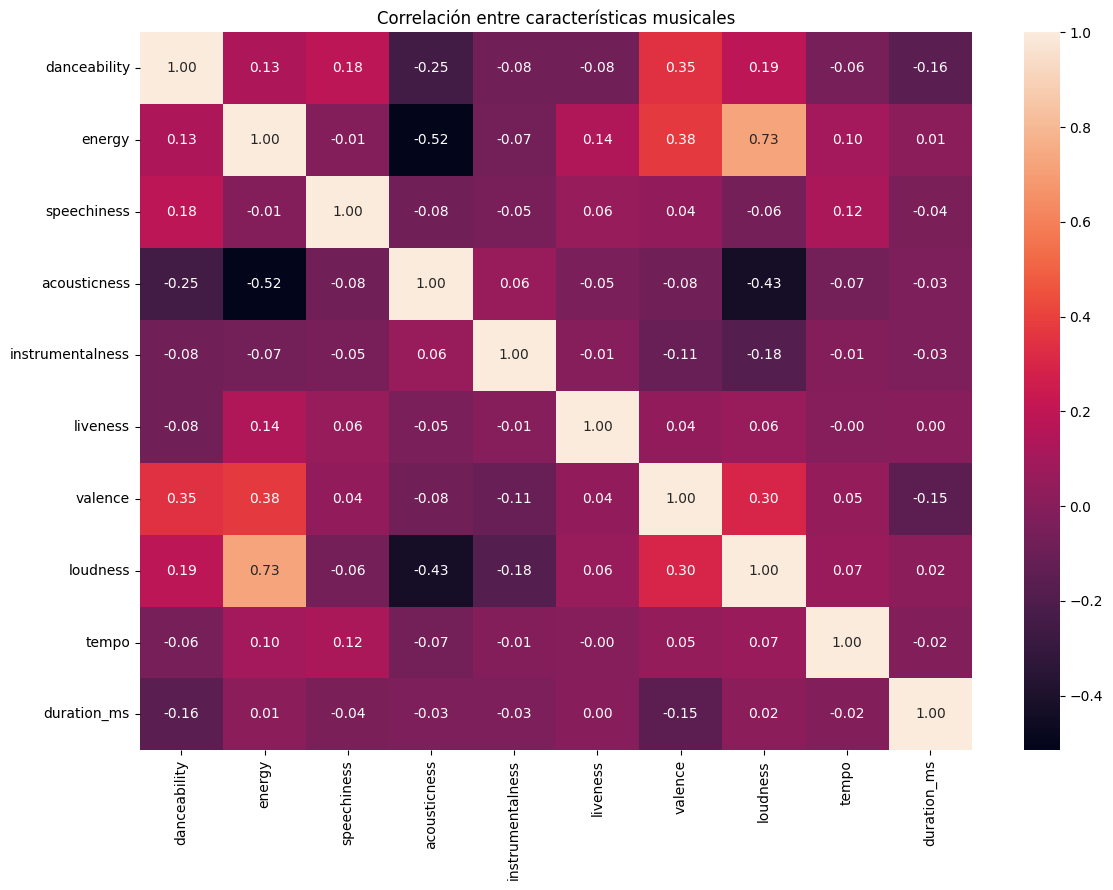

In [38]:
plt.figure(figsize=(12, 9))

sns.heatmap(
    df[audio_features].corr(),
    annot=True,
    fmt=".2f"
)

plt.title("Correlación entre características musicales")
plt.tight_layout()
plt.show()

## 12. Identificación de valores atípicos

Los valores atípicos pueden afectar diferentes algoritmos de minería de datos.

Para identificarlos se utilizará el criterio del rango intercuartílico (IQR):

$$
IQR = Q_3-Q_1
$$

Se considerará potencialmente atípica una observación fuera del intervalo:

$$
[Q_1-1.5(IQR),\ Q_3+1.5(IQR)]
$$

In [39]:
def detectar_outliers(df, variable):
    
    q1 = df[variable].quantile(0.25)
    q3 = df[variable].quantile(0.75)
    
    iqr = q3 - q1
    
    lim_inf = q1 - 1.5 * iqr
    lim_sup = q3 + 1.5 * iqr
    
    outliers = df[
        (df[variable] < lim_inf) |
        (df[variable] > lim_sup)
    ]
    
    return outliers, lim_inf, lim_sup

In [40]:
outliers_streams, lim_inf, lim_sup = detectar_outliers(
    df,
    "streams"
)

print(
    "Número de posibles outliers:",
    len(outliers_streams)
)

print(f"Límite inferior: {lim_inf:,.0f}")
print(f"Límite superior: {lim_sup:,.0f}")

Número de posibles outliers: 831
Límite inferior: -127,534,186
Límite superior: 235,743,802


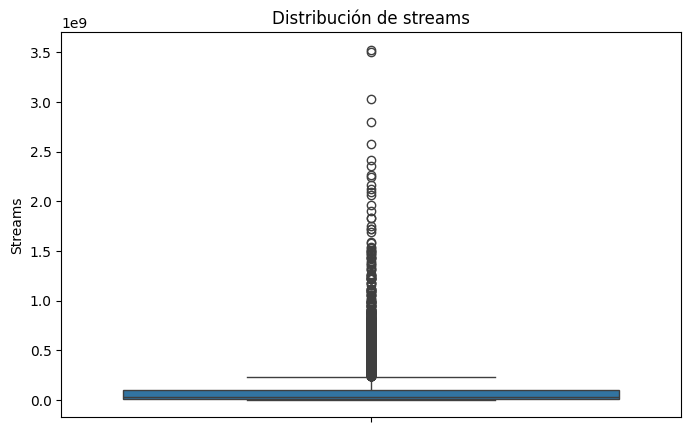

In [41]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    y="streams"
)

plt.title("Distribución de streams")
plt.ylabel("Streams")

plt.show()

## 14. Transformación de `streams`

El número de reproducciones presenta una distribución altamente asimétrica: unas pocas canciones pueden acumular cantidades de reproducciones mucho mayores que la mayoría.

Para facilitar su análisis se utilizará una transformación logarítmica:

$$
streams_{log} = \log(1+streams)
$$

La transformación reduce la influencia de valores extremadamente grandes y permite visualizar mejor la distribución.

In [42]:
df["streams_log"] = np.log1p(
    df["streams"]
)

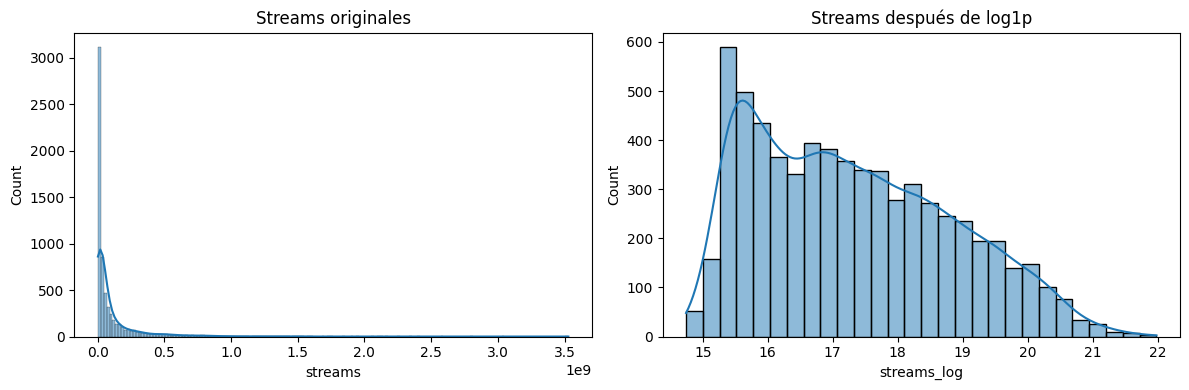

In [43]:
fig, axes = plt.subplots(
    1, 2,
    figsize=(12, 4)
)

sns.histplot(
    df["streams"],
    kde=True,
    ax=axes[0]
)

axes[0].set_title("Streams originales")

sns.histplot(
    df["streams_log"],
    kde=True,
    ax=axes[1]
)

axes[1].set_title("Streams después de log1p")

plt.tight_layout()
plt.show()

## 15. Construcción de la variable `popular`

Para la regresión logística se necesita una variable dependiente categórica/binaria.

Se construirá `popular` utilizando el número de reproducciones (`streams`). Una canción será considerada popular si pertenece al **25 % superior** de canciones según su número de reproducciones.

Esto permite transformar una variable continua en una variable binaria:

$$
popular =
\begin{cases}
1 & \text{si } streams \geq Q_{0.75}\\
0 & \text{si } streams < Q_{0.75}
\end{cases}
$$

In [44]:
stream_threshold = df["streams"].mean()

df["popular"] = (
    df["streams"] >= stream_threshold
).astype(int)

print(
    f"Umbral de popularidad: "
    f"{stream_threshold:,.0f} streams"
)

Umbral de popularidad: 108,964,721 streams


In [45]:
df["popular"].value_counts()

popular
0    4976
1    1537
Name: count, dtype: int64

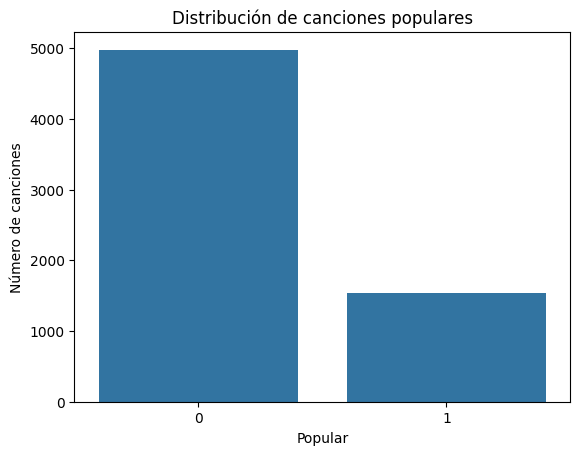

In [46]:
sns.countplot(
    data=df,
    x="popular"
)

plt.title("Distribución de canciones populares")
plt.xlabel("Popular")
plt.ylabel("Número de canciones")

plt.show()

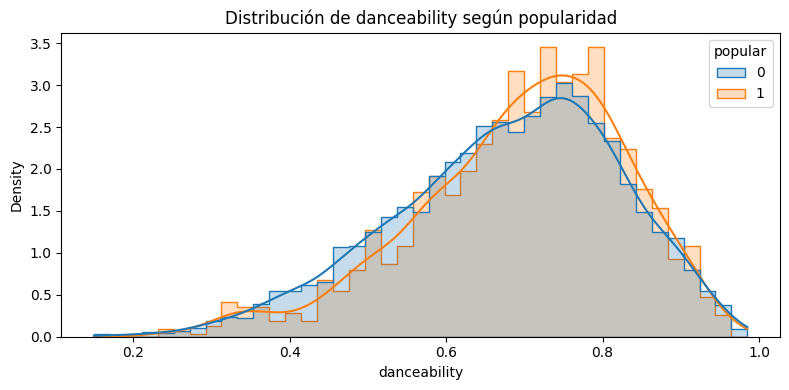

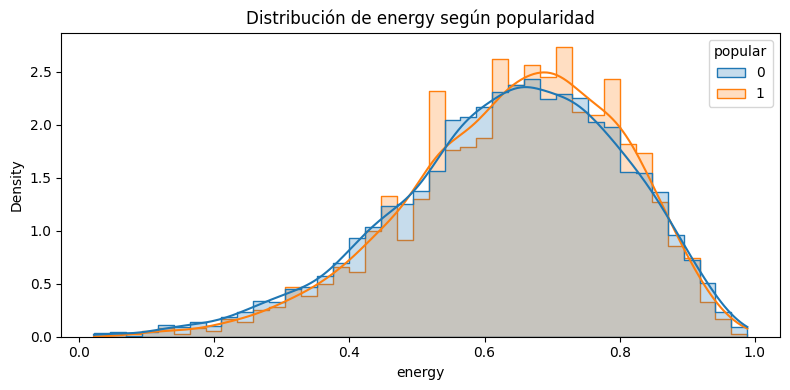

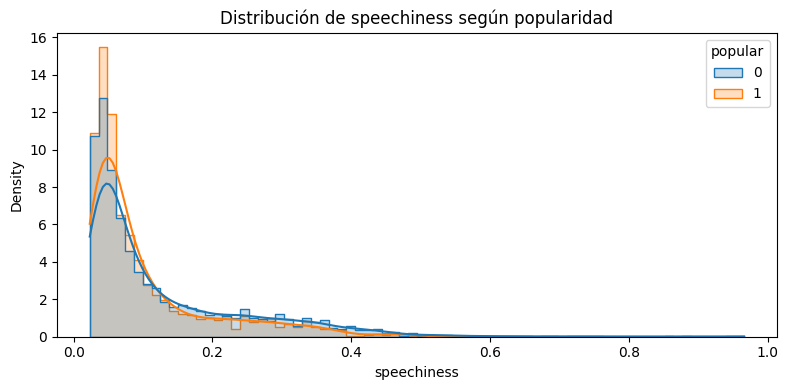

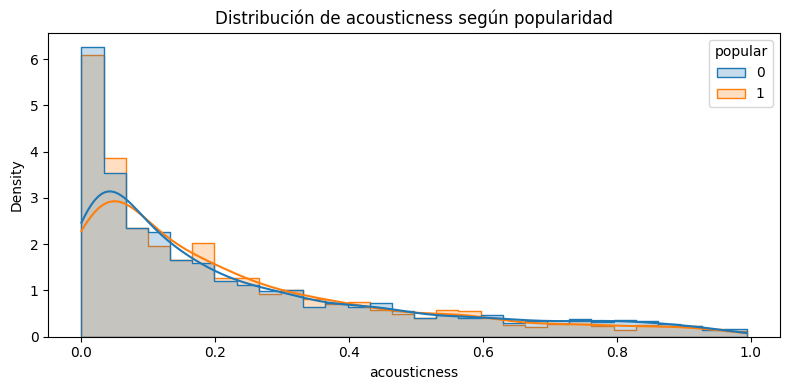

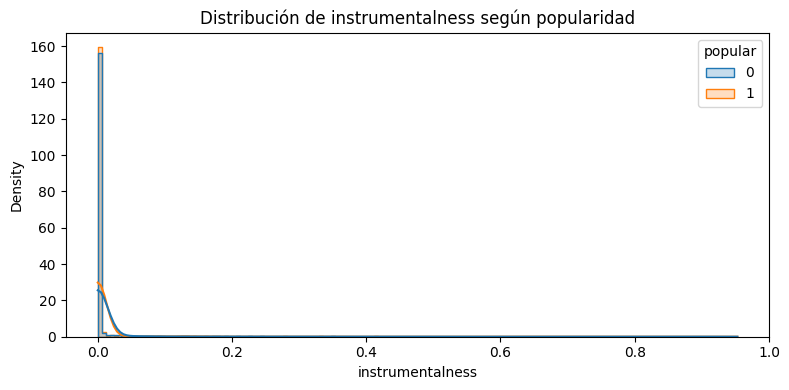

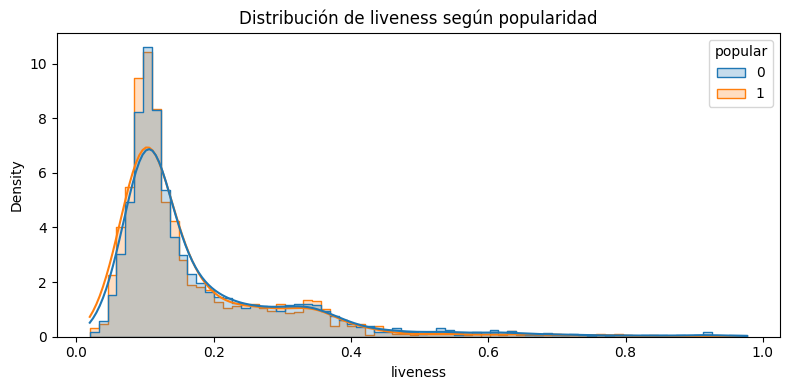

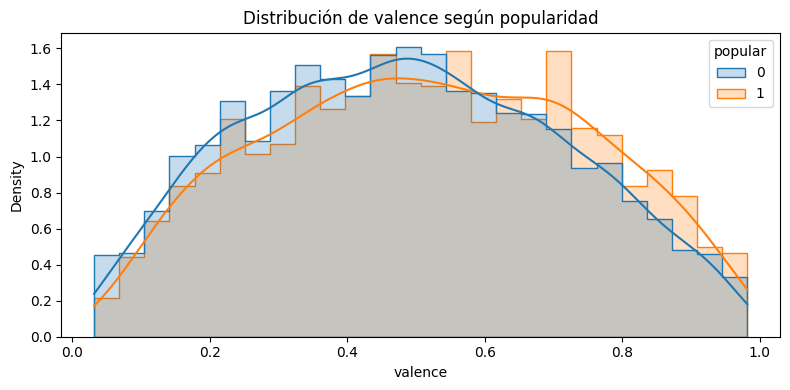

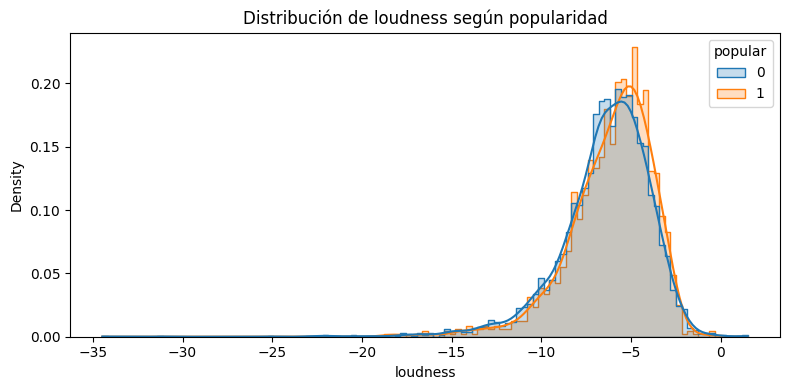

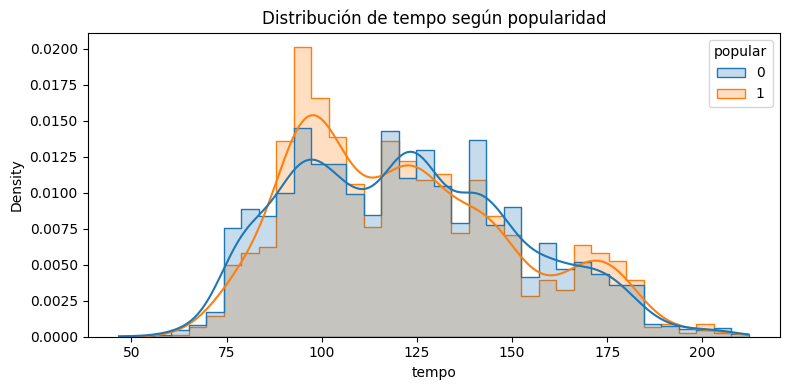

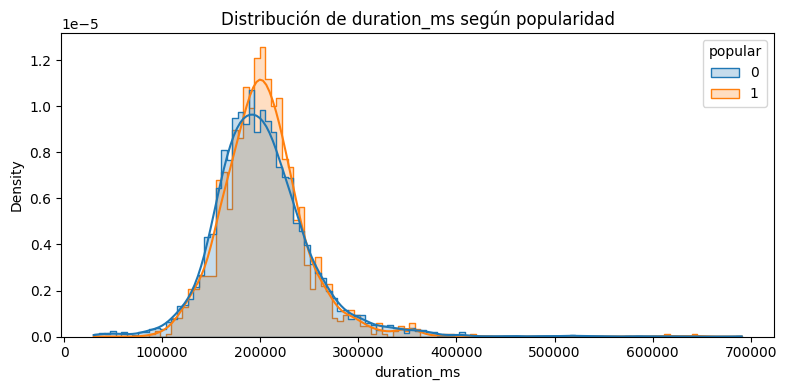

In [47]:
for col in audio_features:
    
    plt.figure(figsize=(8, 4))
    
    sns.histplot(
        data=df,
        x=col,
        hue="popular",
        kde=True,
        element="step",
        stat="density",
        common_norm=False
    )
    
    plt.title(f"Distribución de {col} según popularidad")
    plt.tight_layout()
    plt.show()

## 16. Estandarización

Las variables numéricas del conjunto de datos se encuentran en diferentes escalas. Por ejemplo, `duration_ms` está expresada en milisegundos, `tempo` en BPM, `loudness` en decibeles, mientras que características como `danceability` y `valence` toman valores entre 0 y 1.

Para evitar que las variables con valores numéricamente mayores tengan una influencia desproporcionada en los modelos que utilizan distancias o magnitudes, se realizará una estandarización mediante el **z-score**.

$$
z = \frac{x-\mu}{\sigma}
$$

donde $x$ representa el valor original, $\mu$ la media de la variable y $\sigma$ su desviación estándar.

Después de la transformación, las variables tendrán aproximadamente una media de 0 y una desviación estándar de 1.

La estandarización se aplicará únicamente a las características musicales que serán utilizadas posteriormente en los modelos.

In [48]:
from sklearn.preprocessing import StandardScaler

audio_features = [
    "danceability",
    "energy",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "loudness",
    "tempo",
    "duration_ms"
]

scaler = StandardScaler()

df_scaled = pd.DataFrame(
    scaler.fit_transform(
        df[audio_features]
    ),
    columns=audio_features,
    index=df.index
)

df_scaled.head()

,danceability,energy,speechiness,acousticness,instrumentalness,liveness,valence,loudness,tempo,duration_ms
0,0.467,-0.058,-0.512,-0.432,-0.166,-0.688,0.139,0.127,-0.039,-0.286
1,-2.319,0.719,5.387,-0.631,-0.166,1.520,-0.244,0.029,2.347,-0.181
2,-2.326,1.666,-0.416,-0.962,-0.166,-0.584,-1.130,0.442,0.881,0.415
3,-0.435,-0.070,3.800,0.205,-0.166,0.969,0.760,-0.429,1.557,1.673
4,0.037,0.877,-0.608,-0.820,-0.166,-0.758,0.862,0.609,-0.853,-0.184


In [49]:
df_scaled.describe().T[
    ["mean", "std", "min", "max"]
]

,mean,std,min,max
danceability,-0.000,1.000,-3.750,2.139
energy,0.000,1.000,-3.730,2.139
speechiness,0.000,1.000,-0.870,7.441
acousticness,-0.000,1.000,-0.967,3.094
instrumentalness,0.000,1.000,-0.166,12.516
liveness,-0.000,1.000,-1.162,5.772
valence,-0.000,1.000,-2.028,2.157
loudness,-0.000,1.000,-11.090,3.099
tempo,-0.000,1.000,-2.563,3.060
duration_ms,-0.000,1.000,-3.505,9.923


In [50]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import re

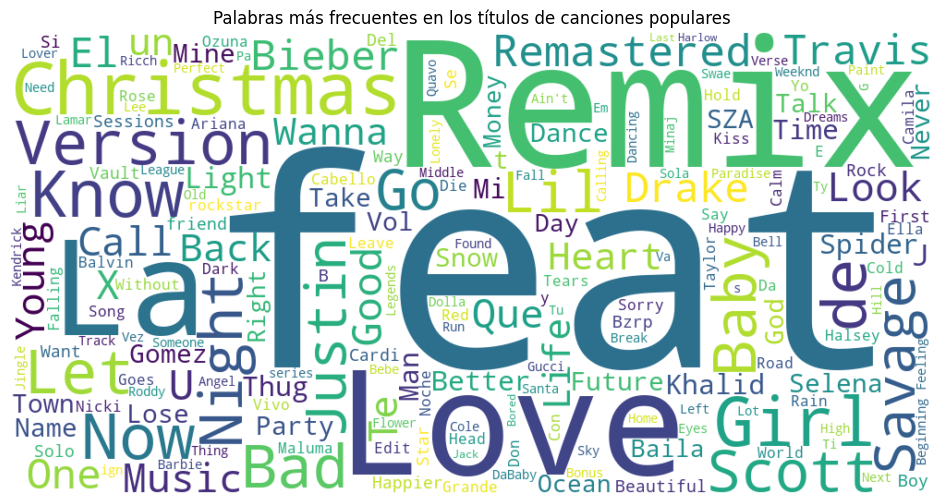

In [51]:
popular_songs = df[
    df["popular"] == 1
].copy()

track_text = " ".join(
    popular_songs["track_name"]
    .dropna()
    .astype(str)
)

wordcloud_tracks = WordCloud(
    width=1000,
    height=500,
    background_color="white",
    collocations=False
).generate(track_text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud_tracks, interpolation="bilinear")
plt.axis("off")
plt.title("Palabras más frecuentes en los títulos de canciones populares")
plt.show()

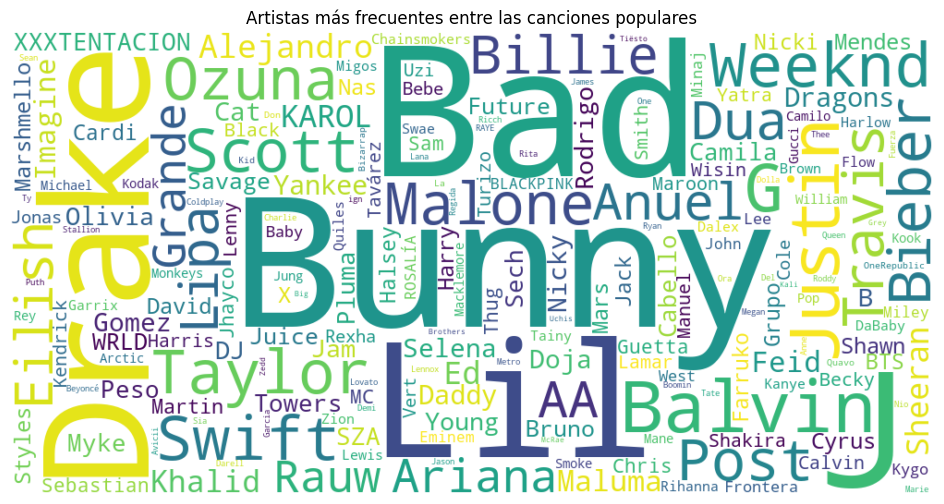

In [52]:
artist_text = " ".join(
    popular_songs["artist_names"]
    .dropna()
    .astype(str)
)

wordcloud_artists = WordCloud(
    width=1000,
    height=500,
    background_color="white",
    collocations=False
).generate(artist_text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud_artists, interpolation="bilinear")
plt.axis("off")
plt.title("Artistas más frecuentes entre las canciones populares")
plt.show()

In [53]:
popular_songs = (
    df[df["popular"] == 1]
    .sort_values("streams", ascending=False)
)

popular_songs[
    [
        "track_name",
        "artist_names",
        "streams",
        "weeks_on_chart"
    ]
].reset_index(drop=True)

,track_name,artist_names,streams,weeks_on_chart
0,Blinding Lights,The Weeknd,3528450184,224
1,Shape of You,Ed Sheeran,3509169565,333
2,Someone You Loved,Lewis Capaldi,3029241037,270
3,Perfect,Ed Sheeran,2797600939,363
4,As It Was,Harry Styles,2580052047,102
...,...,...,...,...
1532,Daylight,Harry Styles,109292793,9
1533,BUTTERFLY EFFECT,Travis Scott,109160313,72
1534,exile (feat. Bon Iver),"Taylor Swift, Bon Iver",109139485,10
1535,Easier,5 Seconds of Summer,109119377,13


In [54]:
# Normalize streams and weeks on chart to [0, 1]

df["streams_norm"] = (
    (df["streams"] - df["streams"].min()) /
    (df["streams"].max() - df["streams"].min())
)

df["weeks_norm"] = (
    (df["weeks_on_chart"] - df["weeks_on_chart"].min()) /
    (df["weeks_on_chart"].max() - df["weeks_on_chart"].min())
)

# Popularity index
STREAMS_WEIGHT = 0.70
WEEKS_WEIGHT = 0.30

df["popularity_index"] = (
    STREAMS_WEIGHT * df["streams_norm"] +
    WEEKS_WEIGHT * df["weeks_norm"]
)

In [55]:
popular_index = (
    df[
        [
            "track_name",
            "artist_names",
            "streams",
            "weeks_on_chart",
            "popularity_index"
        ]
    ]
    .sort_values(
        "popularity_index",
        ascending=False
    )
    .reset_index(drop=True)
)

popular_index.head(20)

,track_name,artist_names,streams,weeks_on_chart,popularity_index
0,Shape of You,Ed Sheeran,3509169565,333,0.968
1,Blinding Lights,The Weeknd,3528450184,224,0.883
2,Perfect,Ed Sheeran,2797600939,363,0.852
3,Someone You Loved,Lewis Capaldi,3029241037,270,0.821
4,lovely (with Khalid),"Billie Eilish, Khalid",2417312282,308,0.731
5,Believer,Imagine Dragons,2120386471,367,0.720
6,Sunflower - Spider-Man: Into the Spider-Verse,"Post Malone, Swae Lee",2063374994,275,0.634
7,Watermelon Sugar,Harry Styles,2351753978,205,0.634
8,Say You Won't Let Go,James Arthur,1959283644,297,0.631
9,As It Was,Harry Styles,2580052047,102,0.595


## 16. Dataset preprocesado

Finalmente, se construirá un dataset que reúna la información necesaria para las siguientes etapas del análisis.

Se conservarán las variables descriptivas de las canciones, las variables relacionadas con su desempeño y las características musicales.

Las características musicales originales se conservarán para facilitar la interpretación de los resultados, mientras que sus versiones estandarizadas estarán disponibles para los algoritmos que requieran variables en una escala comparable.

La variable `popular` también se conservará como una variable derivada que podrá utilizarse posteriormente en tareas de clasificación.

In [56]:
df_preprocessed = pd.concat(
    [
        df[
            [
                "id",
                "track_name",
                "artist_names",
                "streams",
                "weeks_on_chart",
                "popular",
                "popularity_index"
            ]
        ].copy(),
        df_scaled.add_suffix("_scaled")
    ],
    axis=1
)

df_preprocessed.head()

,id,track_name,artist_names,streams,weeks_on_chart,popular,popularity_index,danceability_scaled,energy_scaled,speechiness_scaled,acousticness_scaled,instrumentalness_scaled,liveness_scaled,valence_scaled,loudness_scaled,tempo_scaled,duration_ms_scaled
0,000xQL6tZNLJzIrtIgxqSl,Still Got Time (feat. PARTYNEXTDOOR),"ZAYN, PARTYNEXTDOOR",107527761,17,0,0.034,0.467,-0.058,-0.512,-0.432,-0.166,-0.688,0.139,0.127,-0.039,-0.286
1,003eoIwxETJujVWmNFMoZy,Growing Pains,Alessia Cara,9944865,2,0,0.002,-2.319,0.719,5.387,-0.631,-0.166,1.520,-0.244,0.029,2.347,-0.181
2,003vvx7Niy0yvhvHt4a68B,Mr. Brightside,The Killers,512388123,125,1,0.203,-2.326,1.666,-0.416,-0.962,-0.166,-0.584,-1.130,0.442,0.881,0.415
3,00B7TZ0Xawar6NZ00JFomN,Best Life (feat. Chance The Rapper),"Cardi B, Chance the Rapper",11985346,2,0,0.003,-0.435,-0.070,3.800,0.205,-0.166,0.969,0.760,-0.429,1.557,1.673
4,00Blm7zeNqgYLPtW6zg8cj,One Right Now (with The Weeknd),"Post Malone, The Weeknd",301860377,30,1,0.083,0.037,0.877,-0.608,-0.820,-0.166,-0.758,0.862,0.609,-0.853,-0.184


In [57]:
df_preprocessed.to_csv("spotify_preprocessed.csv", index=False)